# Problem 1: Real GDP across US states


In [1]:
import os
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv 
load_dotenv()

from states import STATES, REGION   # state codes + region mapping

# API key - only needed if we don't already have the data cached (see download_panel below)
FRED_API_KEY = os.environ.get("FRED_API_KEY", "")
FRED_URL = "https://api.stlouisfed.org/fred/series/observations"

# cache the downloads locally so we don't have to re-hit the API every time we re-run this
CACHE_DIR = "data"
os.makedirs(CACHE_DIR, exist_ok=True)


## 1.1 Question 1: Real GDP across US states

### 1. Download the data

For each state we need two FRED series: `XXRGSP` (real GDP) and `XXPOP` (population).
We wrote a helper function, `fetch_series`, that calls the FRED `series/observations`
endpoint for one series and returns it as a `pandas.Series` indexed by year. We loop
over `STATES` twice, once for RGSP and once for POP, to build two data frames with
years as rows and states as columns, and cache the raw downloads to
`data/RGSP_raw.csv` and `data/POP_raw.csv` so we don't have to re-download everything
every time we rerun the notebook.


In [2]:
def fetch_series(series_id, api_key=FRED_API_KEY):
    ''' download one FRED series and return it as a pandas Series indexed by year '''

    params = {"series_id": series_id, "api_key": api_key, "file_type": "json"}
    r = requests.get(FRED_URL, params=params, timeout=30)
    r.raise_for_status()

    obs = r.json()["observations"]
    df = pd.DataFrame(obs)[["date", "value"]]
    df["year"] = pd.to_datetime(df["date"]).dt.year
    df["value"] = pd.to_numeric(df["value"], errors="coerce")  # FRED uses "." for missing

    return df.set_index("year")["value"]


def download_panel(suffix, cache_name):
    ''' download <state><suffix> for all 50 states into one years x states data frame '''

    cache_path = os.path.join(CACHE_DIR, cache_name)
    if os.path.exists(cache_path):
        return pd.read_csv(cache_path, index_col=0)

    # only reach this point (and need the API key) if we don't already have a cached copy
    assert FRED_API_KEY, "No FRED API key found, and no cached data at " + cache_path

    data = {}
    for state in STATES:
        data[state] = fetch_series(state + suffix)
        time.sleep(0.05)  # be a little polite to the API

    panel = pd.DataFrame(data)
    panel.index.name = "year"
    panel.to_csv(cache_path)

    return panel


# build the RGSP and POP panels, one column per state, using the cache if we have it already
RGSP = download_panel("RGSP", "RGSP_raw.csv")   # millions of chained 2017 dollars
POP  = download_panel("POP",  "POP_raw.csv")    # thousands of persons

print("RGSP:", RGSP.shape, "years", RGSP.index.min(), "-", RGSP.index.max())
print("POP: ", POP.shape,  "years", POP.index.min(),  "-", POP.index.max())


RGSP: (29, 50) years 1997 - 2025
POP:  (126, 50) years 1900 - 2025


### 2. Align years and drop states with missing data

`RGSP` and `POP` don't cover exactly the same years. Population data usually goes
further back, and the most recent year can be missing from one of them. We first
keep only the years that appear in both, then drop any state that still has a
missing value somewhere in that window.


In [3]:
# restrict both panels to the years they have in common
common_years = RGSP.index.intersection(POP.index)
RGSP_c = RGSP.loc[common_years]
POP_c = POP.loc[common_years]

# a state is only kept if it has a complete record (both series) over that window
states_kept = [s for s in STATES if RGSP_c[s].notna().all() and POP_c[s].notna().all()]
dropped = [s for s in STATES if s not in states_kept]

RGSP_c = RGSP_c[states_kept]
POP_c = POP_c[states_kept]

print(f"{len(common_years)} years ({common_years.min()}-{common_years.max()}), {len(states_kept)} states kept")
if dropped:
    print("states dropped for missing data:", dropped)


29 years (1997-2025), 50 states kept


We are left with 29 years (1997 to 2025) and all 50 states. No state had to be
dropped for missing data in this window.


### 3. Real GDP per person

`RGSP` is in **millions** of dollars and `POP` is in **thousands** of persons, so

$$y_{i,t} = \frac{RGSP_{i,t}\times 10^6}{POP_{i,t}\times 10^3} = \frac{RGSP_{i,t}}{POP_{i,t}}\times 1000$$

gives real GDP per person in (chained 2017) dollars.


In [4]:
y = RGSP_c / POP_c * 1000   # dollars per person

t_first, t_last = y.index.min(), y.index.max()
print("t_first =", t_first, " t_last =", t_last)
y.head()


t_first = 1997  t_last = 2025


,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
1997,35807.856017,67457.123805,39605.821967,34540.435110,44733.982939,48684.486108,63014.935839,69748.742898,41134.250699,46911.500176,...,37102.024341,42174.514399,44434.405916,41775.745777,36306.218308,47526.867411,50234.997381,33247.961542,42878.542989,50533.611371
1998,36863.947606,65447.615023,42314.201621,35420.860909,47077.134837,52015.826788,64858.950003,75916.652555,42529.012498,49460.461189,...,39371.282272,44354.433604,46674.180385,43470.604533,37702.830612,49921.971948,52711.999932,34070.822349,44443.046546,51671.614120
1999,38109.166834,64218.079096,44847.009375,37139.571517,49945.163875,54495.451702,66684.318338,80773.895942,43950.848785,51932.811521,...,40972.511127,45309.731770,47756.958006,44701.469972,39683.531512,51854.555973,56063.474824,35248.609795,46096.274488,53933.886848
2000,37890.553669,61194.847467,43547.244441,35656.771403,52498.582072,55175.331373,68549.087470,80609.074828,43236.432557,50771.619813,...,42502.024227,44011.670280,47263.240816,43951.174915,40754.374051,52480.115939,55131.873516,35065.779534,46254.567595,53842.201092
2001,37704.140491,63142.679505,43782.422868,35491.800142,51757.417416,54827.668563,68846.332550,82600.078673,43690.131776,50463.135060,...,42741.552458,43526.444806,47867.499715,43895.275899,41948.440356,53685.088358,53103.134426,35304.174732,46781.860367,57288.383668


### 4. Highest and lowest $y_{i,t}$

For $t_{first}$ and $t_{last}$ we report the state with the highest and the lowest
$y_{i,t}$, the ratio between them, and the average across states.


In [5]:
def report_extremes(t):
    ''' print the highest/lowest state, their ratio, and the average, for one year '''

    row = y.loc[t]
    s_max, v_max = row.idxmax(), row.max()
    s_min, v_min = row.idxmin(), row.min()
    avg = row.mean()

    print(f"year {t}:")
    print(f"  highest: {s_max}  ${v_max:,.0f}")
    print(f"  lowest:  {s_min}  ${v_min:,.0f}")
    print(f"  ratio highest/lowest: {v_max/v_min:.2f}")
    print(f"  average across states: ${avg:,.0f}")
    print()

# report both endpoints of the sample
report_extremes(t_first)
report_extremes(t_last)


year 1997:
  highest: DE  $69,749
  lowest:  ID  $32,063
  ratio highest/lowest: 2.18
  average across states: $44,593

year 2025:
  highest: NY  $94,702
  lowest:  MS  $42,434
  ratio highest/lowest: 2.23
  average across states: $64,674



In 1997 Delaware has the highest $y_{i,t}$ (\$69,749) and Idaho the lowest
(\$32,063), a ratio of 2.18. By 2025 New York is highest (\$94,702) and Mississippi
lowest (\$42,434), a ratio of 2.23. So the gap between the richest and poorest state
is, if anything, slightly wider by the end of the sample, even though the average
across states has risen from \$44,593 to \$64,674.


### 5. Figure

Two panels: (i) $y_{i,t}$ against $t$ for a handful of states plus the average
across all states, and (ii) $y_{i,t}$ divided by the average across states in the
same year, for *all* states (so every state's line hovers around 1).


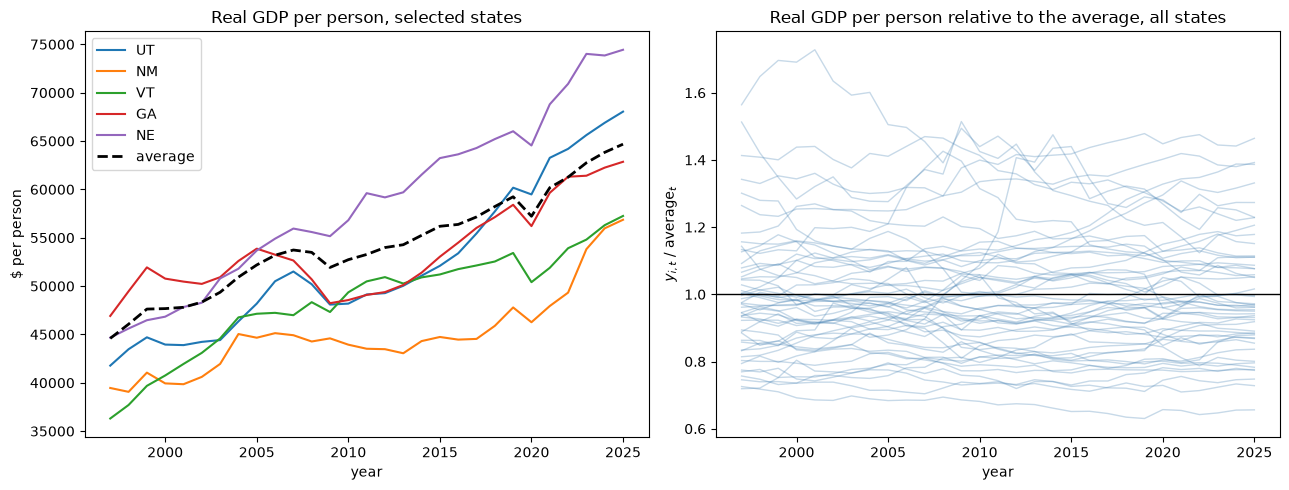

In [6]:
# states to highlight in panel i)
candidates = ["UT", "NM", "VT", "GA", "NE"]
chosen_states = [s for s in candidates if s in y.columns][:5]

avg_y = y.mean(axis=1)
rel_y = y.div(avg_y, axis=0)   # y_it / average_t, for all states -- reused in Question 4 below

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# panel i): levels for a few states plus the cross-state average
for s in chosen_states:
    axes[0].plot(y.index, y[s], label=s)
axes[0].plot(y.index, avg_y, color="black", linewidth=2, linestyle="--", label="average")
axes[0].set_title("Real GDP per person, selected states")
axes[0].set_xlabel("year")
axes[0].set_ylabel("$ per person")
axes[0].legend()

# panel ii): every state relative to that year's average, so lines cluster around 1
for s in y.columns:
    axes[1].plot(rel_y.index, rel_y[s], color="steelblue", alpha=0.3, linewidth=1)
axes[1].axhline(1.0, color="black", linewidth=1)
axes[1].set_title("Real GDP per person relative to the average, all states")
axes[1].set_xlabel("year")
axes[1].set_ylabel(r"$y_{i,t}$ / average$_t$")

fig.tight_layout()
fig.savefig("problem1_fig1.png", dpi=150)
plt.show()


## 1.2 Question 2: Dispersion over time

For each year we compute the standard deviation across states of $\log y_{i,t}$,
and plot it against the year. This is a standard measure of cross-sectional
dispersion (sigma-convergence): if it trends down, states are becoming more
similar in GDP per person over time.


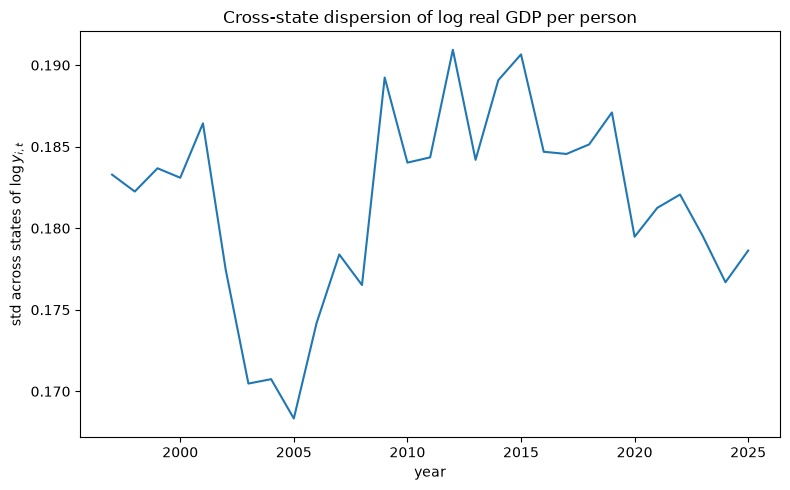

std in 1997: 0.1833
std in 2025:  0.1786
highest: 2012  (0.1909)
lowest:  2005  (0.1683)


In [7]:
log_y = np.log(y)
std_by_year = log_y.std(axis=1)   # cross-state std of log y, one number per year

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(std_by_year.index, std_by_year.values)
ax.set_xlabel("year")
ax.set_ylabel(r"std across states of $\log y_{i,t}$")
ax.set_title("Cross-state dispersion of log real GDP per person")
fig.tight_layout()
fig.savefig("problem1_fig2.png", dpi=150)
plt.show()

print(f"std in {t_first}: {std_by_year.loc[t_first]:.4f}")
print(f"std in {t_last}:  {std_by_year.loc[t_last]:.4f}")
print(f"highest: {std_by_year.idxmax()}  ({std_by_year.max():.4f})")
print(f"lowest:  {std_by_year.idxmin()}  ({std_by_year.min():.4f})")


**Describe what the figure shows. Is there a clear trend?**

There is no single clear trend over the full period. The series moves in swings
tied to the business cycle rather than drifting steadily in one direction.
Dispersion falls to its lowest point in 2005 (0.168), then rises sharply and stays
elevated and volatile through the 2010s (roughly 0.184-0.191, peaking in 2012),
consistent with the 2008 financial crisis hitting states unevenly. It falls again
around 2019-2020 and drifts down toward 2024, before ticking back up slightly in
2025. Overall, the std falls only slightly from 1997 (0.183) to 2025 (0.179), but
that small net change hides a much bigger swing in between.


## 1.3 Question 3: Convergence across states

For each state the average annual growth rate between $t_{first}$ and $t_{last}$ is

$$g_i = \frac{\log y_{i,t_{last}} - \log y_{i,t_{first}}}{t_{last}-t_{first}}$$

We regress $g_i$ on $\log y_{i,t_{first}}$ with `np.polyfit`; a negative slope $b$
means poorer states (low initial $y$) grew faster, which is absolute convergence.


In [8]:
T = t_last - t_first

g = (log_y.loc[t_last] - log_y.loc[t_first]) / T   # one number per state
x0 = log_y.loc[t_first]                              # log y_i,t_first, one number per state

b, a = np.polyfit(x0, g, 1)     # g = a + b*x0  (np.polyfit returns [slope, intercept])
corr = np.corrcoef(x0, g)[0, 1]

print(f"a = {a:.5f}, b = {b:.5f}")
print(f"correlation(g_i, log y_i,t_first) = {corr:.3f}")


a = 0.11809, b = -0.00980
correlation(g_i, log y_i,t_first) = -0.389


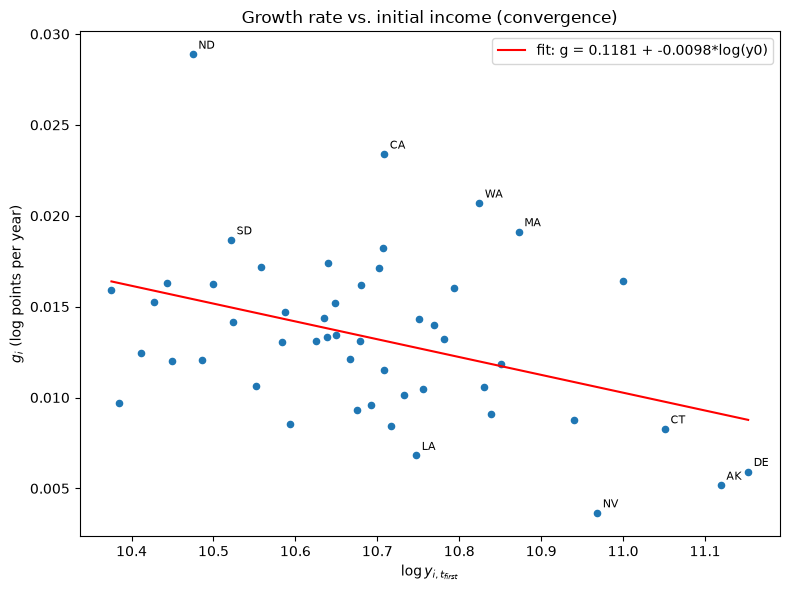

highest g_i:
 ND    0.028886
CA    0.023389
WA    0.020697
MA    0.019120
SD    0.018669
dtype: float64

lowest g_i:
 NV    0.003652
AK    0.005174
DE    0.005929
LA    0.006811
CT    0.008271
dtype: float64


In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x0, g, s=20)

xs = np.linspace(x0.min(), x0.max(), 100)
ax.plot(xs, a + b*xs, color="red", label=f"fit: g = {a:.4f} + {b:.4f}*log(y0)")

# label the five states with the highest and the five with the lowest g_i
top5 = g.sort_values(ascending=False).head(5)
bot5 = g.sort_values(ascending=True).head(5)
for s in pd.concat([top5, bot5]).index:
    ax.annotate(s, (x0[s], g[s]), textcoords="offset points", xytext=(4, 4), fontsize=8)

ax.set_xlabel(r"$\log y_{i,t_{first}}$")
ax.set_ylabel(r"$g_i$ (log points per year)")
ax.set_title("Growth rate vs. initial income (convergence)")
ax.legend()
fig.tight_layout()
fig.savefig("problem1_fig3.png", dpi=150)
plt.show()

print("highest g_i:\n", top5)
print("\nlowest g_i:\n", bot5)


In [10]:
lam = -np.log(1 + b*T) / T   # annual speed of convergence
h = np.log(2) / lam           # half-life

print(f"lambda = {lam:.5f} (per year)")
print(f"h      = {h:.2f} years")


lambda = 0.01146 (per year)
h      = 60.49 years


**Describe the figure. How closely do the points follow the fitted line?**

The slope is negative ($b = -0.0098$) and the correlation is a moderate $-0.389$,
so there is a real but noisy convergence pattern: states that started poorer in
1997 tended to grow faster, but initial income only explains part of the variation
in growth rates. The implied speed of convergence is $\lambda \approx 1.1\%$ per
year, with a half-life of about 60 years, much slower than the classic ~2%/year
rule of thumb from the convergence literature, which fits a longer historical
sample than ours.

The scatter is fairly spread out around the line rather than tightly clustered.
Some of the fastest-growing states (ND, CA, WA, MA, SD) sit well above the fitted
line, so their growth is not explained by having a low starting income. ND in
particular grew fast from a middling starting point, most likely on the back of
its shale oil boom, while CA, WA and MA started from *above*-average income and
still grew quickly, driven by tech and finance. On the other side, DE and CT sit
below the line: both started rich and grew slowly, which is what the convergence
story predicts. But NV, AK and LA also sit below the line despite not being
especially rich to begin with, so their slow growth (housing bust, oil prices,
hurricane damage) is a story about specific shocks, not just initial income.


## 1.4 Question 4: Regional patterns 

Using `REGION` from `states.py`, we compute, for every year and every region, the
average within that region of $y_{i,t}/\text{average}_t$ (the same relative measure
as panel ii of Question 1), via a `groupby`.


In [11]:
# map each kept state to its Census region, and count how many states are in each
region_map = {s: REGION[s] for s in states_kept}
n_per_region = pd.Series(region_map).value_counts()
print("states per region:\n", n_per_region)

# reshape rel_y (years x states) to long format, tag each state with its region,
# then average within region and year
rel_long = rel_y.stack().rename("rel").reset_index()
rel_long.columns = ["year", "state", "rel"]
rel_long["region"] = rel_long["state"].map(region_map)

region_avg = rel_long.groupby(["year", "region"])["rel"].mean().unstack()
region_avg.head()


states per region:
 South        16
West         13
Midwest      12
Northeast     9
Name: count, dtype: int64


region,Midwest,Northeast,South,West
year,,,,
1997,0.968332,1.087340,0.951318,1.028682
1998,0.968472,1.087564,0.957887,1.020313
1999,0.962879,1.091557,0.958916,1.021444
2000,0.976595,1.110827,0.943301,1.014661
2001,0.969318,1.119563,0.948591,1.008820


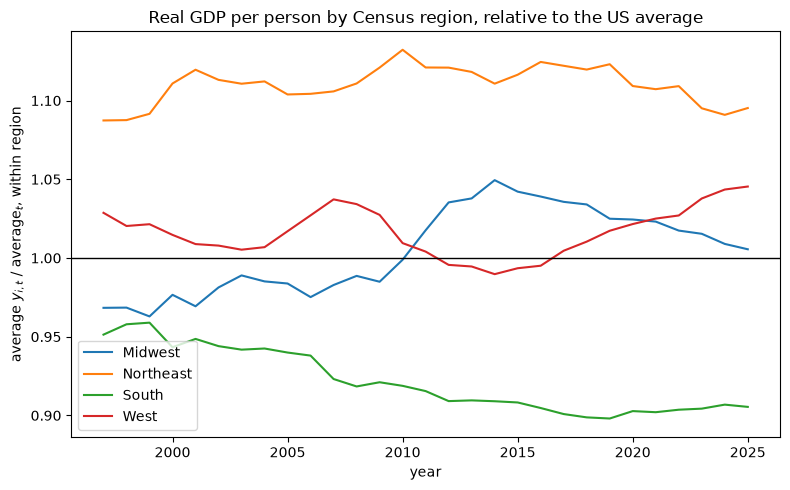

In [12]:
# plot the four regional relative-income series over time
fig, ax = plt.subplots(figsize=(8, 5))
for reg in region_avg.columns:
    ax.plot(region_avg.index, region_avg[reg], label=reg)
ax.axhline(1.0, color="black", linewidth=1)
ax.set_xlabel("year")
ax.set_ylabel(r"average $y_{i,t}$ / average$_t$, within region")
ax.set_title("Real GDP per person by Census region, relative to the US average")
ax.legend()
fig.tight_layout()
fig.savefig("problem1_fig4.png", dpi=150)
plt.show()


In [13]:
# compare each region's relative position in t_first vs. t_last, sorted by size of the move
summary = pd.DataFrame({
    "t_first": region_avg.loc[t_first],
    "t_last": region_avg.loc[t_last],
})
summary["change"] = summary["t_last"] - summary["t_first"]
summary = summary.sort_values("change", key=lambda s: s.abs(), ascending=False)
summary


,t_first,t_last,change
region,,,
South,0.951318,0.905418,-0.045900
Midwest,0.968332,1.005527,0.037194
West,1.028682,1.045378,0.016696
Northeast,1.087340,1.095232,0.007892


**Which region moves the most, and in which direction?**

The South moves the most, and it moves in the "wrong" direction: it falls from
0.951 to 0.905 times the national average, i.e. it becomes relatively poorer even
though the country as a whole is converging in other respects. The Midwest moves
almost as much but the other way, rising from 0.968 to 1.006. It goes from
below-average to essentially at the national average. The West and Northeast barely
move (+0.017 and +0.008 respectively) and stay roughly where they started, with the
Northeast consistently the richest region throughout. So regional convergence is
not uniform: it is really a Midwest-catches-up, South-falls-behind story, not every
region drifting toward the middle.


# Problem 2: The Solow model with a time-varying savings rate 

In [14]:
# Setup 
from SolowModel import SolowModelClass
import numpy as np
import matplotlib.pyplot as plt

model = SolowModelClass()
print(model)

Solow model with:
  alpha = 0.3333 (capital share)
  delta = 0.3000 (depreciation rate)
  s_bar = 0.2500 (long-run savings rate)
  beta  = 0.8333 (discount factor)
  k0    = 0.1000 (initial capital per worker)
  T     = 100 (number of periods)


## 2.1 Question 1: Steady state and baseline simulation

We first compute the analytical steady state and confirm it numerically with a root-finder. We then simulate the model with a constant savings rate as our baseline. 

In [15]:
# a. analytical and numerical steady state
k_star, y_star, c_star = model.steady_state()
k_star_numerical = model.solve_steady_state()

print(f'k* (analytical) = {k_star:.4f}')
print(f'k* (numerical)  = {k_star_numerical:.4f}')
print(f'y* = {y_star:.4f}')
print(f'c* = {c_star:.4f}')

k* (analytical) = 0.7607
k* (numerical)  = 0.7607
y* = 0.9129
c* = 0.6847


The analytical and numerical steady-state values for k* both equal 0.7607, confirming that the root-finder correctly identifies the fixed point of the law of motion (4)

### Baseline simulation

We simulate the model for T periods with a constant savings rate s_t = s̄, starting from k₀ = 0.10

In [16]:
from copy import deepcopy

# b. simulate the baseline (constant savings rate)
sim_baseline = deepcopy(model.simulate(model.par.s_bar))

print(f'c0    = {sim_baseline.c[0]:.4f}')
print(f'c_T-1 = {sim_baseline.c[-1]:.4f}')
print(f'k_T-1 = {sim_baseline.k[-1]:.4f}')

c0    = 0.3481
c_T-1 = 0.6847
k_T-1 = 0.7607


### Figure: Baseline paths 

We plot the savings rate, capital, and consumption per worker over time.

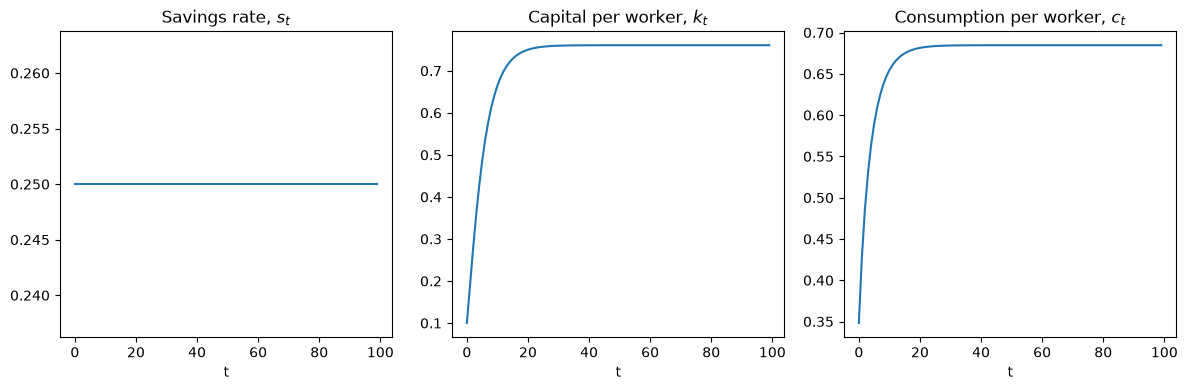

In [17]:
# c. plot the baseline paths
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(sim_baseline.s)
axes[0].set_title('Savings rate, $s_t$')
axes[0].set_xlabel('t')

axes[1].plot(sim_baseline.k)
axes[1].set_title('Capital per worker, $k_t$')
axes[1].set_xlabel('t')

axes[2].plot(sim_baseline.c)
axes[2].set_title('Consumption per worker, $c_t$')
axes[2].set_xlabel('t')

fig.tight_layout()
plt.show()

As expected, capital and consumption per worker converge monotonically towards their steady-state values, while the savings rate stays constant at s̄ = 0.25.

### Sanity checks

we verify the simulator with two checks: An economy starting at k* should remain there, and an economy with s = 0 should have capital decaying at rate (1-δ) each period. 

In [18]:
# d. sanity checks
# Check 1: an economy starting in steady state stays there
k_star, _, _ = model.steady_state()
sim_check1 = model.simulate(model.par.s_bar, k0=k_star)
assert np.allclose(sim_check1.k, k_star), 'capital should stay at k* when starting there'

# Check 2: with s = 0, capital decays as k_t = (1-delta)^t * k0
sim_check2 = model.simulate(0.0, k0=model.par.k0)
t = np.arange(model.par.T)
k_theory = (1 - model.par.delta)**t * model.par.k0
assert np.allclose(sim_check2.k, k_theory), 'capital should decay at rate (1-delta) with s=0'

print('Both sanity checks passed.')

Both sanity checks passed.


## 2.2 Question 2: The time-varying savings rule

We implement the savings rule s_t = s̄ + (s0 - s̄)φ^t in 's_path', and simulate the model for four combinations of (s0, φ), together with the baseline. 

In [19]:
# a. implement and test s_path
s_test = model.s_path(s0=0.30, phi=0.50)
print(f's_0  = {s_test[0]:.4f} (should be 0.30)')
print(f's_1  = {s_test[1]:.4f}')
print(f's_99 = {s_test[-1]:.4f} (should be close to s_bar = 0.25)')

s_0  = 0.3000 (should be 0.30)
s_1  = 0.2750
s_99 = 0.2500 (should be close to s_bar = 0.25)


### Simulating the four combinations 

We simulate the four (s0, φ) combinations together with the baseline, and plot s_t, k_t and c_t for all five paths. 

In [20]:
# b. simulate the four combinations
combinations = [(0.30, 0.50), (0.40, 0.80), (0.10, 0.50), (0.60, 0.60)]

sims = {}
sims['baseline'] = sim_baseline

for s0, phi in combinations:
    s_vec = model.s_path(s0, phi)
    sims[(s0, phi)] = deepcopy(model.simulate(s_vec))

for key, sim in sims.items():
    print(f'{key}: k_T-1 = {sim.k[-1]:.4f}')

baseline: k_T-1 = 0.7607
(0.3, 0.5): k_T-1 = 0.7607
(0.4, 0.8): k_T-1 = 0.7607
(0.1, 0.5): k_T-1 = 0.7607
(0.6, 0.6): k_T-1 = 0.7607


All five k_T - 1 values are identical (0.7607). This is because every rule has φ < 1, so s_t converges back to s̄ over time, and with T=100 periods there is ample time for capital to reach the same long-run steady state regardless of the initial savings rate. Only the transition path differs between the rules, not the final destination. 

### Figure: all five paths compared

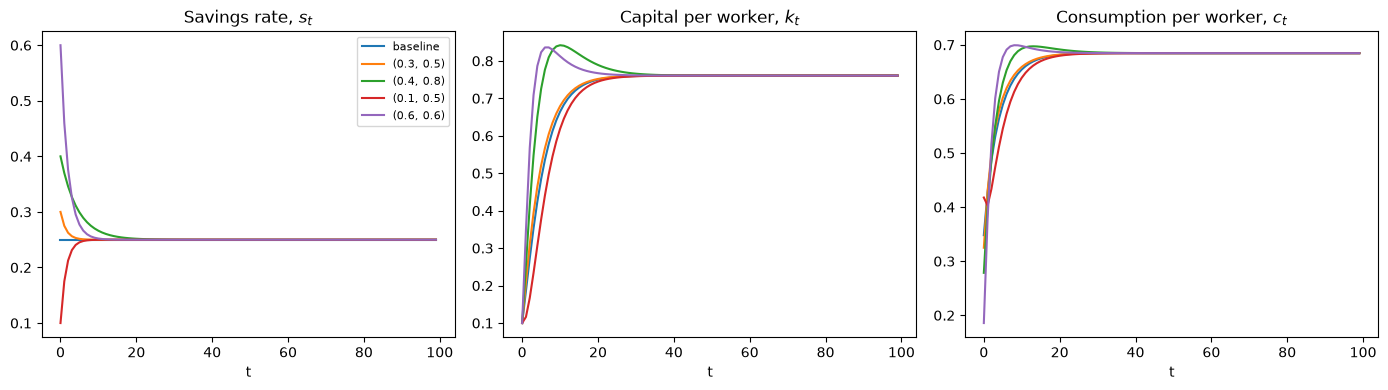

In [21]:
# c. plot all five paths together
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for key, sim in sims.items():
    axes[0].plot(sim.s, label=str(key))
    axes[1].plot(sim.k, label=str(key))
    axes[2].plot(sim.c, label=str(key))

axes[0].set_title('Savings rate, $s_t$')
axes[1].set_title('Capital per worker, $k_t$')
axes[2].set_title('Consumption per worker, $c_t$')
for ax in axes: ax.set_xlabel('t')

axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

A higher s0 gives an overshoot in capital and consumption before they settle down again. A lower s0 gives a dip first, then recovery. φ controls the speed: low φ means the savings rate goes back to s̄ fast, high φ means it stays high/low for longer. 

## 2.3 Question 3: welfare

We compute W for the baseline and the four rules, and compare each to the baseline. 

In [22]:
# a. welfare of the baseline and the four combinations
W_baseline = model.welfare(sim_baseline.c)

results = {'baseline': W_baseline}
for s0, phi in combinations:
    results[(s0, phi)] = model.welfare(sims[(s0, phi)].c)

print(f'{"rule":<15}{"W":>10}{"W - W_baseline":>18}')
for key, W in results.items():
    print(f'{str(key):<15}{W:>10.4f}{W - W_baseline:>18.4f}')

rule                    W    W - W_baseline
baseline          -3.9944            0.0000
(0.3, 0.5)        -3.9857            0.0087
(0.4, 0.8)        -4.0914           -0.0970
(0.1, 0.5)        -4.1460           -0.1516
(0.6, 0.6)        -4.3407           -0.3463


Only (0.3, 0.5) beats the baseline. The others give lower welfare, even though capital ends up the same for all of them. This is because welfare cares about the whole consumption path, not just the end point, starting with a high s0 means less consumption, and that hurts W since early consumption counts more (discounting with beta). You couldn't really tell this from the figure alone, since all the paths end at the same k_T - 1, but W picks up the differences in how they get there. 

## 2.4 Question 4: Finding the best rule

### Grid search

We compute W on a grid over s0 and φ, and find the best point on the grid.

s0  = 0.3061
phi = 0.2327
W   = -3.9844


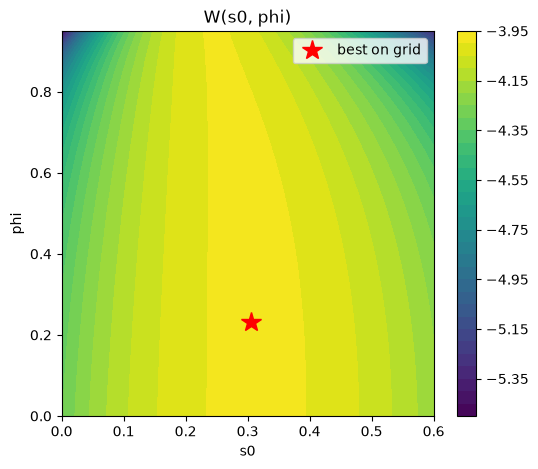

In [23]:
# a. grid search
s0_grid = np.linspace(0, 0.60, 50)
phi_grid = np.linspace(0, 0.95, 50)

W_grid = np.empty((len(s0_grid), len(phi_grid)))
for i, s0 in enumerate(s0_grid):
    for j, phi in enumerate(phi_grid):
        W_grid[i, j] = model.evaluate(s0, phi)

# find the best point on the grid
i_best, j_best = np.unravel_index(np.argmax(W_grid), W_grid.shape)
s0_best_grid = s0_grid[i_best]
phi_best_grid = phi_grid[j_best]
W_best_grid = W_grid[i_best, j_best]

print(f's0  = {s0_best_grid:.4f}')
print(f'phi = {phi_best_grid:.4f}')
print(f'W   = {W_best_grid:.4f}')

#plot 
S0, PHI = np.meshgrid(s0_grid, phi_grid, indexing='ij')
fig, ax = plt.subplots(figsize=(6,5))
cs = ax.contourf(S0, PHI, W_grid, levels=30)
ax.plot(s0_best_grid, phi_best_grid, 'r*', markersize=15, label='best on grid')
ax.set_xlabel('s0')
ax.set_ylabel('phi')
ax.set_title('W(s0, phi)')
fig.colorbar(cs)
ax.legend()
plt.show()


### Numerical optimization 

We use the best grid point as starting guess and run a numerical optimizer to refine it.

In [24]:
# b. numerical optimization 
from scipy import optimize

obj = lambda x: -model.evaluate(x[0], x[1])  # negative because we minimize
x0 = [s0_best_grid, phi_best_grid]

result = optimize.minimize(obj, x0, method='Nelder-Mead')

s0_best, phi_best = result.x
W_best = -result.fun

print(f's0  = {s0_best:.4f} (grid: {s0_best_grid:.4f})')
print(f'phi = {phi_best:.4f} (grid: {phi_best_grid:.4f})')
print(f'W   = {W_best:.4f} (grid: {W_best_grid:.4f})')

s0  = 0.3115 (grid: 0.3061)
phi = 0.2207 (grid: 0.2327)
W   = -3.9843 (grid: -3.9844)


The optimizer barely improves on the grid point (W goes from -3.9844 to -3.9843). Makes sense since the grid already had 50x50 points and landed close to the true optimum. The surface also look pretty flat around there in the countour plot, so there isn't much left to gain. 

### Best rule vs baseline 

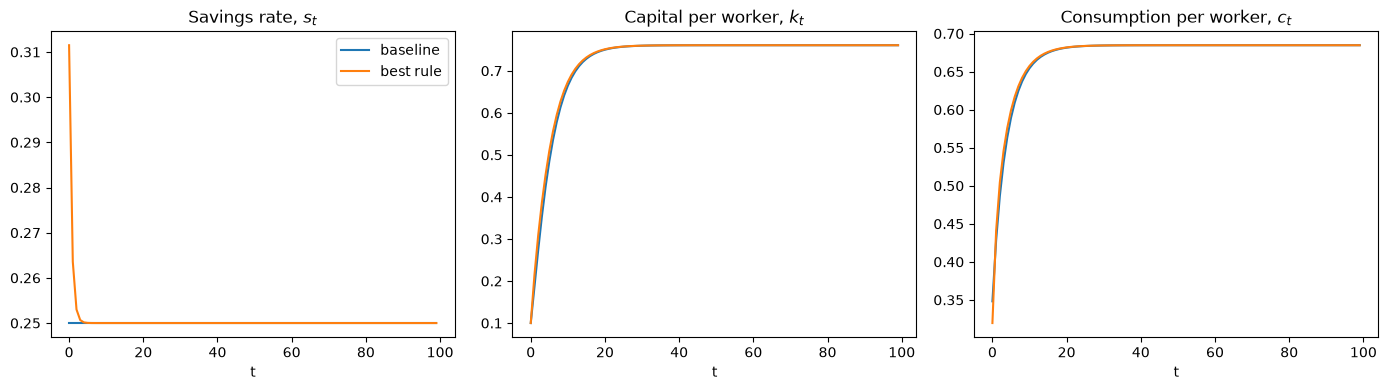

c0 (best rule) = 0.3196
c0 (baseline)  = 0.3481
first period where c_t (best) > c_t (baseline): t = 1


In [25]:
# c. simulate and plot the best rule 
s_best_vec = model.s_path(s0_best, phi_best)
sim_best = deepcopy(model.simulate(s_best_vec))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(sim_baseline.s, label='baseline')
axes[0].plot(sim_best.s, label='best rule')
axes[1].plot(sim_baseline.k, label='baseline')
axes[1].plot(sim_best.k, label='best rule')
axes[2].plot(sim_baseline.c, label='baseline')
axes[2].plot(sim_best.c, label='best rule')

axes[0].set_title('Savings rate, $s_t$')
axes[1].set_title('Capital per worker, $k_t$')
axes[2].set_title('Consumption per worker, $c_t$')
for ax in axes: ax.set_xlabel('t')
axes[0].legend()

fig.tight_layout()
plt.show()

# report c0 and first period where c_t exceeds baseline 
c0_best = sim_best.c[0]
first_above = np.argmax(sim_best.c > sim_baseline.c)

print(f'c0 (best rule) = {c0_best:.4f}')
print(f'c0 (baseline)  = {sim_baseline.c[0]:.4f}')
print(f'first period where c_t (best) > c_t (baseline): t = {first_above}')

c0 is lower for the best rule than the baseline (0.3196 vs 0.3481), since s0 ≈ 0.31 is higher than s̄, so more gets saved and less consumed at first. But it only takes one period before consumption overtakes the baseline, after that the extra capital pays off. 

## 2.5 Question 5: Three-parameter rule

Now s_inf is also free instead of fixed at s̄. We optimize over all three parameters.

In [26]:
# a. optimize over (s0, phi, s_inf)
obj3 = lambda x: -model.evaluate3(x[0], x[1], x[2])
x0_3 = [s0_best, phi_best, model.par.s_bar]
result3 = optimize.minimize(obj3, x0_3, method='Nelder-Mead')
s0_best3, phi_best3, s_inf_best3 = result3.x
W_best3 = -result3.fun
print(f's0    = {s0_best3:.4f}')
print(f'phi   = {phi_best3:.4f}')
print(f's_inf = {s_inf_best3:.4f}')
print(f'W     = {W_best3:.4f}')
print(f'improvement over Q4: {W_best3 - W_best:.4f}')

s0    = 0.3139
phi   = 0.6709
s_inf = 0.1989
W     = -3.9670
improvement over Q4: 0.0173


In [27]:
# b. compare K_T - 1 with k* from question 1
s_best3_vec = model.s_path3(s0_best3, phi_best3, s_inf_best3)
sim_best3 = deepcopy(model.simulate(s_best3_vec))

print(f'k_T-1 (best 3-param rule) = {sim_best3.k[-1]:.4f}')
print(f'k* (from Q1)              = {k_star:.4f}')

k_T-1 (best 3-param rule) = 0.5400
k* (from Q1)              = 0.7607


k_T - 1 for the best three parameter rule is not the same as k* from question 1 (0.5400 vs 0.7607). That confirms what we expected, since s_inf ends up around 0.20 instead of s_bar at 0.25. Capital converges to a lower steady state because the long run savings rate is actually lower than in the baseline. 

## 2.6 Question 6: An alternative functional form 

We propose an exponential decay rule s_t = s_bar + (s0 - s_bar) * exp(minus lambda times t) as an alternative to the original power decay rule. It has the same basic shape, starting at s0 and settling at s_bar, but with a different transition curve. 

In [28]:
# a. optimize over (s0, lam)
obj_alt = lambda x: -model.evaluate_alt(x[0], x[1])
x0_alt = [s0_best, 0.2]

result_alt = optimize.minimize(obj_alt, x0_alt, method='Nelder-Mead')
s0_best_alt, lam_best_alt = result_alt.x
W_best_alt = -result_alt.fun

print(f's0    = {s0_best_alt:.4f}')
print(f'lam   = {lam_best_alt:.4f}')
print(f'W     = {W_best_alt:.4f}')

s0    = 0.3115
lam   = 1.5107
W     = -3.9843


In [29]:
# b. summary table comparing Q4, Q5 and Q6
print(f'{"rule":<25}{"W":>10}')
print(f'{"Q4 two parameter":<25}{W_best:>10.4f}')
print(f'{"Q5 three parameter":<25}{W_best3:>10.4f}')
print(f'{"Q6 exponential decay":<25}{W_best_alt:>10.4f}')

rule                              W
Q4 two parameter            -3.9843
Q5 three parameter          -3.9670
Q6 exponential decay        -3.9843


The exponential decay rule from Q6 gives almost the same welfare as the two parameter power rule from Q4, so it does not beat the numbers we found there. The three parameter rule from Q5 is still the best of the three, since letting s_inf be free gives more room to improve welfare than just changing the shape of the transition. 

# Problem 3: A portfolio with a risky and a safe asset


Setup: import packages and load the model with default parameters


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from PortfolioModel import PortfolioModelClass

model = PortfolioModelClass()
print(model)

Portfolio model with:
  mu    = 0.0500, sigma = 0.2000, r = 0.0100
  theta_star = 0.5000, Delta = 0.1000, tau = 0.0100
  gamma = 3.0000 (relative risk aversion)
  W0 = 1.00, T = 40, N = 50,000, seed = 2026


### Testing trade()

Quick sanity check of the trading rule before using it inside the simulator. 
With theta_star=0.50 and delta=0.10, shares more than 0.10 away from the target should be tracked to 0.50; shares withing the band should be left unchanged. 

In [31]:
theta_test=np.array([0.3,0.5,0.65,0.9])
theta_post,traded=model.trade(theta_test)
print(theta_post)
print(traded)


[0.5 0.5 0.5 0.5]
[0.2  0.   0.15 0.4 ]


As expected, shares outside the 0.40 - 0.60 band get traded back to the target of 0.50, while the shares already at the target are left unchanged. This confirms the trading rule works as intended before using it inside the simulator.

## 3.1 Question 1: Returns

**1. Draw the returns**

Draw $\varepsilon_t$ for all periods and all portfolios in one array of shape $(N,T)$ using the given seed, and compute $R_t$.

In [32]:
R=model.draw_returns()

**2. Compare with $\mu$ and $\sigma$**
Report the mean and standard deviation of $\log R_t$ across all draws and compare with $\mu$ and $\sigma$. Report the mean of $R_t$ and compare with $\exp(\mu + \tfrac{1}{2}\sigma^2)$.

In [33]:
logR = np.log(R)
print(f"Mean of log R:  {logR.mean():.4f}  (mu = {model.par.mu:.4f})")
print(f"Std of log R:   {logR.std():.4f}  (sigma = {model.par.sigma:.4f})")
print(f"Mean of R:      {R.mean():.4f}  (exp(mu + 0.5*sigma^2) = {np.exp(model.par.mu + 0.5*model.par.sigma**2):.4f})")

Mean of log R:  0.0500  (mu = 0.0500)
Std of log R:   0.2000  (sigma = 0.2000)
Mean of R:      1.0725  (exp(mu + 0.5*sigma^2) = 1.0725)


**3. Figure: distribution of $R_t$ and value of 1 invested**

A histogram of $R_t$, and the value of 1 invested in the risky asset for 20 portfolios vs. the safe asset, on a log scale.

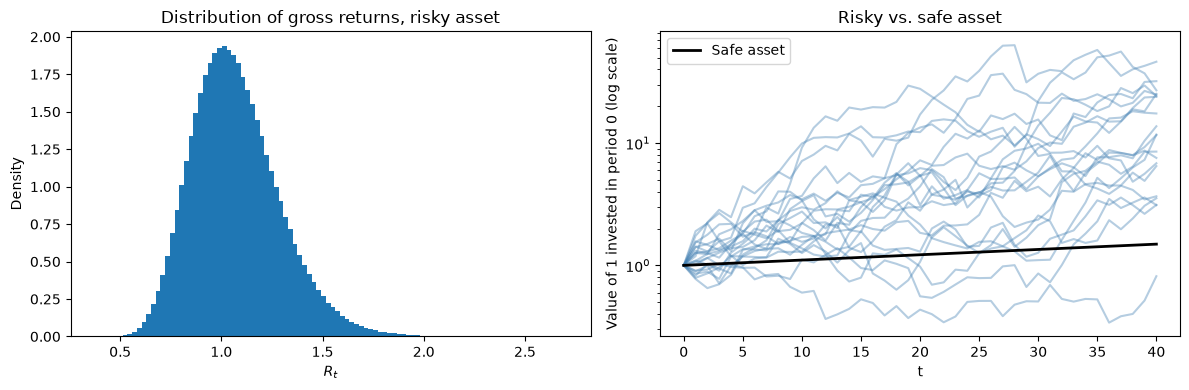

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(R.flatten(), bins=100, density=True)
axes[0].set_xlabel('$R_t$')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of gross returns, risky asset')

value_risky = np.hstack([np.ones((20, 1)), np.cumprod(R[:20, :], axis=1)])
Rf = np.exp(model.par.r)
t_grid = np.arange(model.par.T + 1)
value_safe = Rf**t_grid

for i in range(20):
    axes[1].plot(t_grid, value_risky[i, :], color='steelblue', alpha=0.4)
axes[1].plot(t_grid, value_safe, color='black', linewidth=2, label='Safe asset')
axes[1].set_yscale('log')
axes[1].set_xlabel('t')
axes[1].set_ylabel('Value of 1 invested in period 0 (log scale)')
axes[1].set_title('Risky vs. safe asset')
axes[1].legend()

fig.tight_layout()
plt.show()

## 3.2 Question 2: Simulating the two extreme rules

**1. The simulator**
The simulator loops over the $T$ periods and vectorizes over the $N$ portfolios; it is implemented in `PortfolioModelClass.simulate()`, storing $W_t$ and $\theta_t$ for all periods.

**2. Simulate $\Delta=0$ and $\Delta=1$ ($\tau=0$)**

Use the same drawn returns for both, and report the six numbers for each.

In [35]:
import pandas as pd
model0 = PortfolioModelClass(tau=0.0, Delta=0.0)
model0.simulate(R=R)
model1 = PortfolioModelClass(tau=0.0, Delta=1.0)
model1.simulate(R=R)
table_q2 = pd.DataFrame({'Delta=0': model0.summary(), 'Delta=1': model1.summary()}).T
table_q2

,n_trades,avg_distance,mean_WT,median_WT,p10_WT,EU
Delta=0,39.0,0.039395,5.043602,4.081492,1.793667,-0.067829
Delta=1,0.0,0.191138,8.975620,4.447803,1.485479,-0.076690


**3. Figure: distribution of $W_T$ and $\theta_t$ over time**

A histogram of $W_T$ for the two rules, and the mean of $\theta_t$ against $t$, with a shaded 10th-90th percentile band.

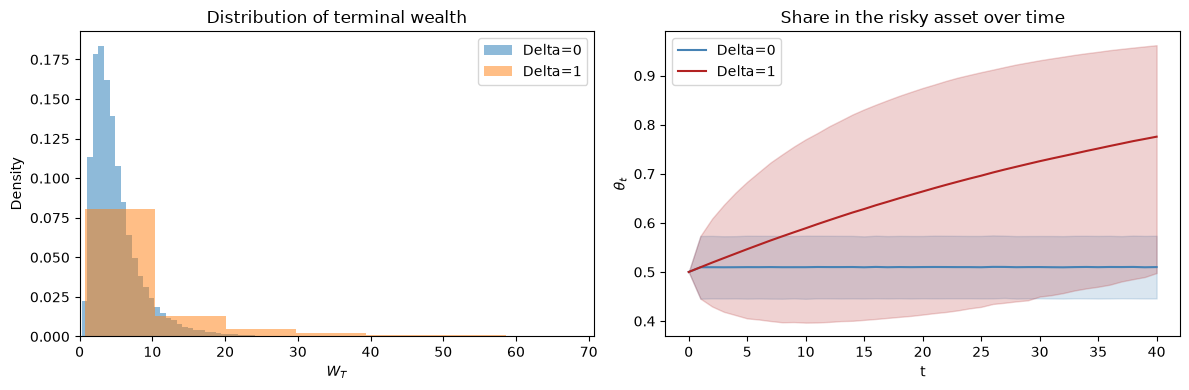

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(model0.sim.W[:, -1], bins=100, alpha=0.5, density=True, label='Delta=0')
axes[0].hist(model1.sim.W[:, -1], bins=100, alpha=0.5, density=True, label='Delta=1')
axes[0].set_xlabel('$W_T$')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of terminal wealth')
axes[0].set_xlim(0, np.percentile(model1.sim.W[:, -1], 99))
axes[0].legend()
t_grid = np.arange(model.par.T + 1)
for m, label, color in [(model0, 'Delta=0', 'steelblue'), (model1, 'Delta=1', 'firebrick')]:
    mean_theta = m.sim.theta.mean(axis=0)
    p10 = np.percentile(m.sim.theta, 10, axis=0)
    p90 = np.percentile(m.sim.theta, 90, axis=0)
    axes[1].plot(t_grid, mean_theta, color=color, label=label)
    axes[1].fill_between(t_grid, p10, p90, color=color, alpha=0.2)
axes[1].set_xlabel('t')
axes[1].set_ylabel(r'$\theta_t$')
axes[1].set_title('Share in the risky asset over time')
axes[1].legend()
fig.tight_layout()
plt.show()

**4. Description**

With $\Delta=1$ the portfolio is never traded, so $\theta_t$ drifts away from 0.50. Since the risky asset has a higher expected return than the safe asset ($\mu=0.05 > r=0.01$), $\theta_t$ drifts upward on average, and the 10th-90th percentile band widens over time as the randomness in returns accumulates.

## 3.3 Question 3: Varying the no-trade band $\Delta$

**1. Table over $\Delta$**
Report the six numbers for each $\Delta$ in one table, with $\tau=0.01$ and the same drawn returns for all of them

In [37]:
Deltas = [0, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20, 0.30, 1]
rows = {}
for Delta in Deltas:
    m = PortfolioModelClass(tau=0.01, Delta=Delta)
    m.simulate(R=R)
    rows[Delta] = m.summary()
table_q3 = pd.DataFrame(rows).T
table_q3.index.name = 'Delta'
table_q3


,n_trades,avg_distance,mean_WT,median_WT,p10_WT,EU
Delta,,,,,,
0.000,39.00000,0.039395,4.962427,4.018396,1.768274,-0.069934
0.025,24.52346,0.039974,4.974622,4.018379,1.769181,-0.069745
0.050,14.33342,0.042948,5.015482,4.035755,1.767369,-0.069505
0.075,8.79048,0.047986,5.073901,4.047645,1.765500,-0.069347
0.100,5.86028,0.054052,5.145886,4.060641,1.759388,-0.069460
0.150,3.15190,0.068029,5.328542,4.104170,1.735272,-0.069950
0.200,1.95026,0.083468,5.559645,4.186286,1.679246,-0.070944
0.300,0.90548,0.117972,6.195680,4.341368,1.536125,-0.073406
1.000,0.00000,0.191138,8.975620,4.447803,1.485479,-0.076690


**2. Figure: trades, distance, and expected utility against $\Delta$**

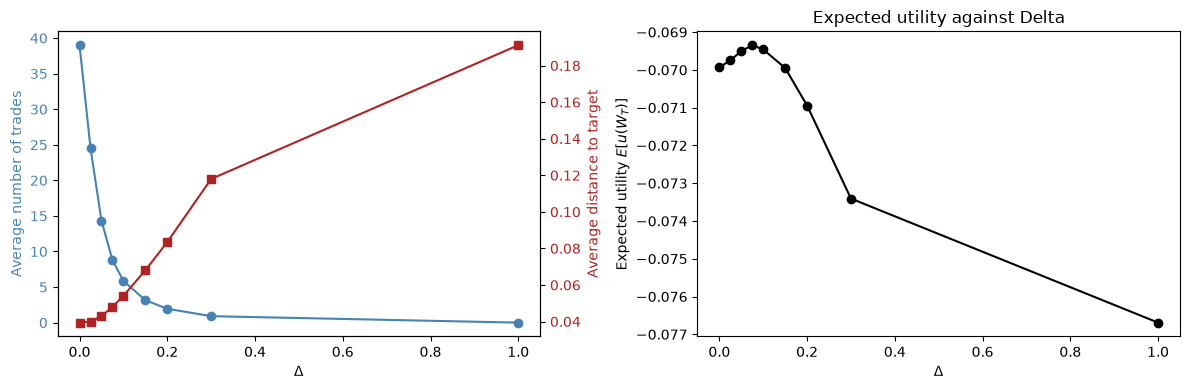

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax1 = axes[0]
ax1.plot(table_q3.index, table_q3['n_trades'], marker='o', color='steelblue', label='Number of trades')
ax1.set_xlabel(r'$\Delta$')
ax1.set_ylabel('Average number of trades', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1b = ax1.twinx()
ax1b.plot(table_q3.index, table_q3['avg_distance'], marker='s', color='firebrick', label='Avg. distance to target')
ax1b.set_ylabel('Average distance to target', color='firebrick')
ax1b.tick_params(axis='y', labelcolor='firebrick')
axes[1].plot(table_q3.index, table_q3['EU'], marker='o', color='black')
axes[1].set_xlabel(r'$\Delta$')
axes[1].set_ylabel('Expected utility $E[u(W_T)]$')
axes[1].set_title('Expected utility against Delta')
fig.tight_layout()
plt.show()

**3. Best $\Delta$**

Which $\Delta$ gives the highest expected utility, and by how much does it beat $\Delta=0$ and $\Delta=1$?

In [39]:
best_Delta = table_q3['EU'].idxmax()
best_EU = table_q3.loc[best_Delta, 'EU']
EU_0 = table_q3.loc[0, 'EU']
EU_1 = table_q3.loc[1, 'EU']
print(f"Best Delta: {best_Delta}")
print(f"EU at best Delta: {best_EU:.6f}")
print(f"Improvement over Delta=0: {best_EU - EU_0:.6f}")
print(f"Improvement over Delta=1: {best_EU - EU_1:.6f}")


Best Delta: 0.075
EU at best Delta: -0.069347
Improvement over Delta=0: 0.000588
Improvement over Delta=1: 0.007343


**4. Description**

As $\Delta$ grows from 0 to the best value (0.075), the **number of trades falls sharply** (from 39.0 to 8.8 per portfolio, a drop of about 77%), while the **average distance to the target rises only modestly** (from 0.039 to 0.048). The wealth statistics barely move over this range: mean $W_T$ rises from 4.96 to 5.07 (+2.3%), median $W_T$ from 4.02 to 4.05, and the 10th percentile is essentially unchanged (1.768 vs. 1.766). Expected utility improves only slightly, from -0.069934 to -0.069347. So going from $\Delta=0$ to the best $\Delta$ saves a large share of the trading costs almost for free, without giving up much precision in tracking the target or much downside protection.

Over the full range up to $\Delta=1$, the picture changes: mean $W_T$ keeps climbing (up to 8.98, i.e. +81% relative to $\Delta=0$), because an untraded portfolio drifts into the risky asset and rides its higher average return, and trading costs disappear entirely. But this comes at the cost of more risk: the 10th percentile of $W_T$ *falls* monotonically as $\Delta$ grows (from 1.77 down to 1.49), and expected utility deteriorates once $\Delta$ passes 0.075, ending up at -0.076690 for $\Delta=1$, clearly worse than the optimum.

Ranking by the **mean** of $W_T$ instead of expected utility would **not** give the same answer: mean $W_T$ increases essentially monotonically in $\Delta$, so it would point to the largest $\Delta$ (never trading) as "best." This is because the mean ignores the downside risk that a risk-averse investor cares about, the CRRA utility with $\gamma=3$ penalizes the low outcomes captured by the falling 10th percentile, which is exactly why expected utility favors a small, disciplined no-trade band around $\Delta=0.075$ rather than letting the portfolio drift unchecked.
